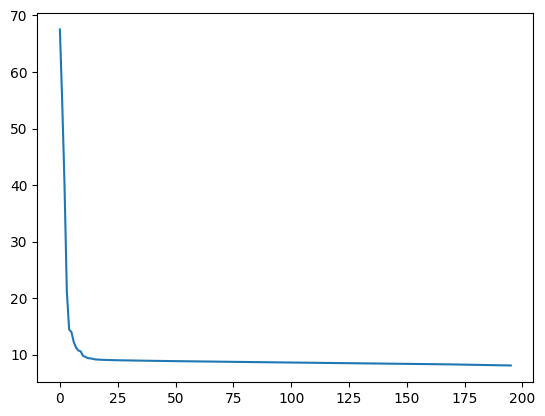

In [1]:
import torch
from torch.linalg import svd
import matplotlib.pyplot as plt

path = "/home/ids/edabier/HSU/SS-HSU_benchmark/experiments"
input_ = torch.load(f"{path}/apex_input.pt")
features = torch.load(f"{path}/apex_low_res_features.pt")
weights = torch.load(f"{path}/apex_upsample_weights.pt").cpu()
features_up = torch.load(f"{path}/apex_upsampled_features.pt")

U,S,Vh = svd(weights, full_matrices=False)
plt.plot(S.detach().numpy())

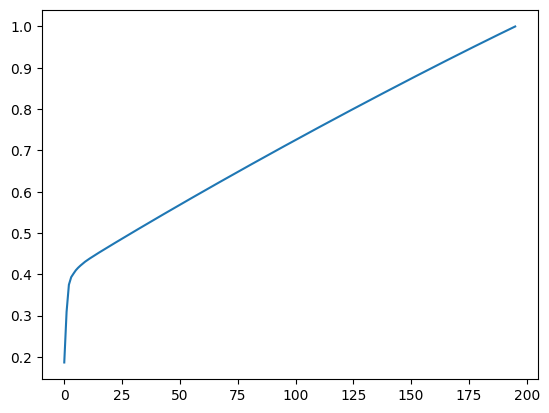

In [7]:
import numpy as np
energy = (S**2).detach().numpy()
energy /= energy.sum()

plt.plot(np.cumsum(energy))

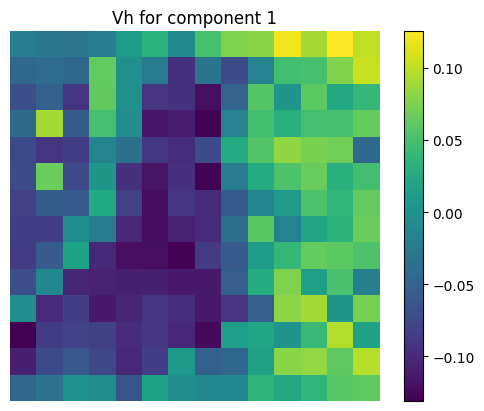

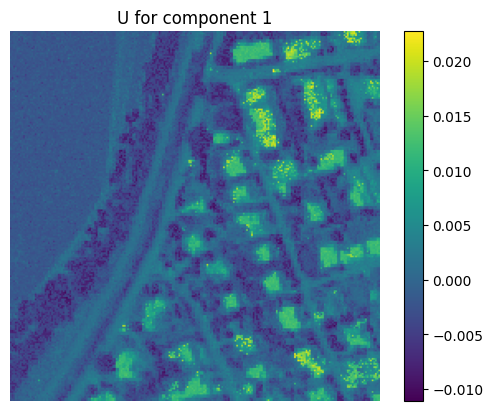

In [41]:
def visualize_component(U, V, k):
    alpha = int(V.shape[0]**0.5)
    H = int(U.shape[0]**0.5)
    plt.imshow(V[k].reshape(alpha, alpha).detach().cpu())
    plt.title(f"Vh for component {k}")
    plt.colorbar()
    plt.axis("off")
    plt.show()

    plt.imshow(U[:, k].reshape(H, H).detach().cpu())
    plt.title(f"U for component {k}")
    plt.colorbar()
    plt.axis("off")
    plt.show()

# for k in [0,1,2,3,4,5,10,20,50,100,150]:
k=1
visualize_component(U, Vh, k)

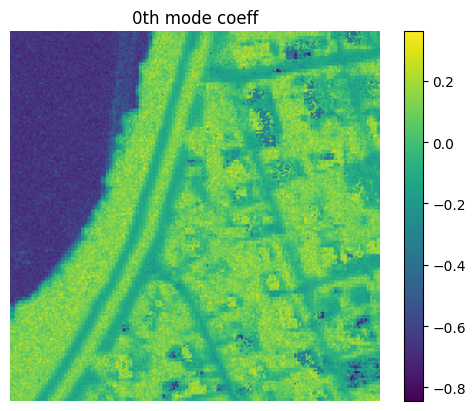

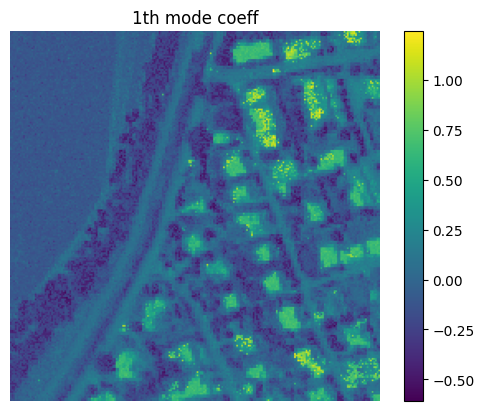

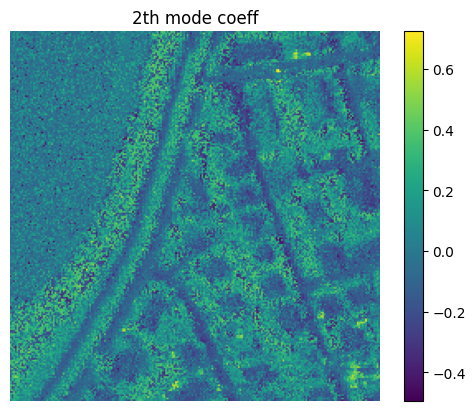

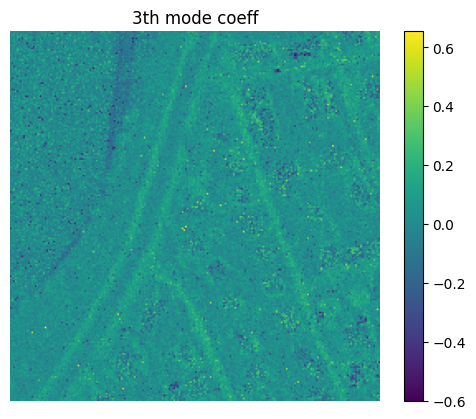

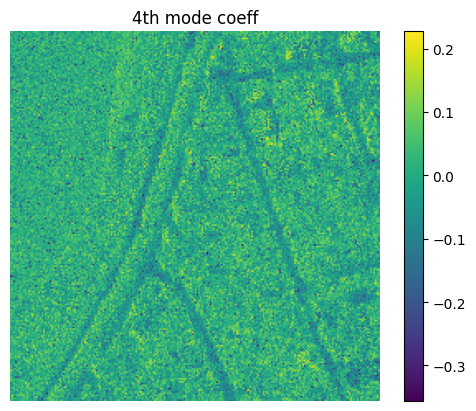

In [44]:
coeff = weights @ Vh.T
for k in range(5):
    plt.imshow(coeff[:, k].reshape(224, 224).detach().cpu())
    plt.axis("off")
    plt.colorbar()
    plt.title(f"{k}th mode coeff")
    plt.show()